In [6]:
import json
import geopandas as gpd
from geopandas.io.arrow import _geopandas_to_arrow
import numpy as np
import shapely
import shapely.geometry
import math
import pyarrow as pa
import pyarrow.parquet as pq

# Guide on storing embeddings

## 1. Introduction

In the 1st CNG Geo-Embeddings sprint, we came up with best practices on exchanging earth embeddings. They are not a strict standard, rather a community recommendation.

Exchanging embeddings involves two stages:
1. Storing embeddings
2. Cataloging them

This notebook provides detail on how to follow the recommendation and adds code snippets to ease implementation.

When embeddings are form a regular grid, use `zarr` (chp. 2). When they are ordered irregularly, use `geoparquet` (chp. 3). In either case, use STAC to catalog them with appropriate metadata.

## 2. Regularly gridded embeddings

When your embeddings are gridded regularly in **both space and time** over the entire area for which you provide embeddings, use `zarr` and add `geo` extension to provide spatial metadata.

Notable examples of when we recommend `zarr` would be Tessera, or Google's AlphaEarth Embeddings. They are gridded regularly in space without any overlap, and in time as exactly one embedding is provided per year.



In [7]:
"to be done"

'to be done'

If you plan to directly embed multiple EO images individually, we recommend you do not use zarr, as the images do not form a regular grid in space (they overlap) and time (differences in acquisition time). You could create a zarr for each image, but this defeats the purpose of having a unified zarr store. In this case, use GeoParquet.

## 3. Irregularly gridded embeddings

If your your data is gridded irregularly over space and/or time, we recommend you store them as GeoParquet, a cloud-optimized columnar data format.

The `geometry` of the GeoParquet file represents the spatial footprint on which the embedding applies, the embedding itself is stored in the `embedding` column.

If you embedd individual EO images, we recommend to create one GeoParquet per EO image.



### 3.1 Saving the data

In our example, we pretend to have computed embeddings for a Sentinel-2-L2A image. Chips from which embeddings were comptued are 224

,id,geometry,embedding
0,0,"POLYGON ((20 50, 20 50.0025, 20.0025 50.0025, ...","[0.4995561986002184, 0.7866711217020672, 0.337..."
1,1,"POLYGON ((20.0023 50, 20.0023 50.0025, 20.0048...","[0.9704653623329355, 0.7037657981963223, 0.377..."
2,2,"POLYGON ((20.0046 50, 20.0046 50.0025, 20.0071...","[0.4979349523697255, 0.8232727915984419, 0.393..."
3,3,"POLYGON ((20.0069 50, 20.0069 50.0025, 20.0094...","[0.4009379560841555, 0.6985653953562635, 0.965..."
4,4,"POLYGON ((20.0092 50, 20.0092 50.0025, 20.0117...","[0.42891240216158844, 0.7675464612423644, 0.66..."


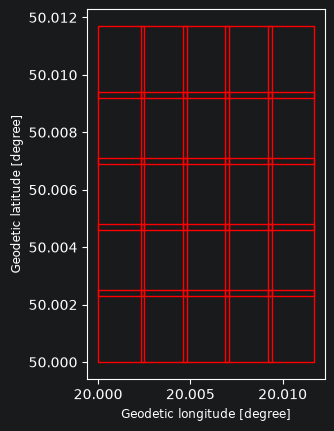

In [8]:
tile_id = "emb_S2A_MSIL2A_20170102T175732_N0500_R141_T13TEF_20230926T044006"

# dummy embeddings dataframe of 25 64-dimensional embeddings, arranged in a 5x5 overlapping grid
num_examples = 25
ids = range(num_examples)

geoms = []
start_lat, start_lon = 50, 20
d_lat, d_lon =  0.0025, 0.0025
overlap = 0.0002
for i in range(int(math.sqrt(num_examples))):
    for j in range(int(math.sqrt(num_examples))):
        footprint = shapely.box(
            start_lon + j * d_lon - j * overlap,
            start_lat + i * d_lat - i * overlap,
            start_lon + j * d_lon + d_lon - j * overlap,
            start_lat + i * d_lat + d_lat - i * overlap,
        ).normalize()
        # print(footprint)
        geoms.append(footprint)

embedding_len = 64
embeddings = [np.random.random(embedding_len) for _ in range(num_examples)]
gdf = gpd.GeoDataFrame({"id": ids, "geometry": geoms, "embedding": embeddings}, crs="EPSG:4326")

gdf.plot(facecolor="none", edgecolor="red", linewidth=1)
gdf.head()

You could save this by running `gdf.to_parquet("out.parquet")` and store the embeddings in a valid GeoParquet file. The issue is that it assignes the embedding column the `List` data type. For improved cloud-native lazy evaluation of the embeddings, using the `FixedSizeList` data type is preferable. Unfortunately, GeoPandas does not support this, but the pyarrow library does.

In [9]:
# 1. Let geopandas build the Arrow table (this attaches the GeoParquet "geo" metadata)
pa_table = _geopandas_to_arrow(gdf, index=None)   # returns a pyarrow.Table

# 2. Build a FixedSizeList array from the "emb" column
flat = np.stack(gdf["embedding"].to_numpy()).reshape(-1)      # flatten all vectors
values = pa.array(flat)                                 # inherits dtype (e.g. float32/float64)
emb_fsl = pa.FixedSizeListArray.from_arrays(values, embedding_len)

# 3. Replace the emb column in the table
i = pa_table.schema.get_field_index("embedding")
new_field = pa.field("embedding", emb_fsl.type)
table = pa_table.set_column(i, new_field, emb_fsl)

# 4. Write out (still a valid GeoParquet because we kept the schema metadata)
pq.write_table(table, f"out/{tile_id}.parquet")

Reading the schema of the file we just created now reveals that the embedding column is a FixedSizeList containing exactly 64 double-precision float numbers.


In [10]:
schema = pq.read_schema(f"out/{tile_id}.parquet")
schema[2]

pyarrow.Field<embedding: fixed_size_list<element: double>[64]>

### 3.1 Cataloging with metadata

We catalog each parquet file as a STAC Item. Lastly, we create a collection to bundle the items.

In [11]:
bbox = gdf.total_bounds.tolist()
item_metadata = {
    "stac_version": "1.1.0",
    "stac_extensions": [
        "https://stac-extensions.github.io/embeddings/v0.0.1/schema.json"  # does not validate, as schema not published yet
    ],
    "type": "Feature",
    "id": "",
    "collection": "terramind_embeddings",
    "links": [
        {
            "rel": "self",
            "href": f"./{tile_id}.json",
            "type": "application/json"
        },
        {
            "rel": "emb:source-data",
            "href": f"https://stac.dataspace.copernicus.eu/v1/collections/sentinel-2-l2a/items/{tile_id}",
            "type": "application/json",
            "title": "Sentinel-2 image from which this embedding was computed."
        }
    ],
    "bbox": bbox,
    "geometry": shapely.geometry.mapping(shapely.box(*bbox)),
    "properties": {
        "datetime": "2017-01-02T17:57:32",  # date of image acquisition
        "gsd": 2240,  # length of grid cells in m
        "title": "Terramind Embedding",
        "description": "Terramind embedding from Sentinel-2-L2A imagery.",
        "licensing": " CC-BY 4.0"
    },
    "assets": {
        "embeddings": {
            "href": f"{tile_id}.parquet",
            "title": "Terramind Embeddings",
            "type": "application/vnd.apache.parquet",
            "roles": [
                "embeddings"
            ]
        }
    }
}
with open(f"out/{tile_id}.json", "w") as f:
    json.dump(item_metadata, f)